In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### A. Încărcarea și curățarea tabelului evaluari

## 1. Încărcarea datelor

In [2]:
angajati = pd.read_csv("angajati_curat.csv",
                parse_dates=["data_nasterii", "data_angajarii", "data_plecarii"])

departamente = pd.read_csv("departamente.csv")

evaluari = pd.read_csv("evaluari.csv")

In [3]:
print("Angajati:", angajati.shape)
angajati.info()
angajati.head()

Angajati: (480, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id_angajat          480 non-null    int64         
 1   nume                480 non-null    object        
 2   prenume             480 non-null    object        
 3   gen                 480 non-null    object        
 4   data_nasterii       480 non-null    datetime64[ns]
 5   data_angajarii      480 non-null    datetime64[ns]
 6   id_departament      480 non-null    int64         
 7   functie             480 non-null    object        
 8   nivel               480 non-null    object        
 9   oras                480 non-null    object        
 10  tip_contract        480 non-null    object        
 11  salariu_brut_lunar  480 non-null    int64         
 12  status              480 non-null    object        
 13  data_plecarii       115 non-nu

,id_angajat,nume,prenume,gen,data_nasterii,data_angajarii,id_departament,functie,nivel,oras,...,salariu_brut_lunar,status,data_plecarii,motiv_plecare,email,nume_departament,varsta,vechime_ani,grupa_vechime,plecat
0,1081,Voicu,Bianca,F,1980-06-09,2018-01-20,60,Manager Suport Clienți,Manager,București,...,8000,Plecat,2023-03-21,Relația cu managerul,bianca.voicu081@technova.ro,Suport Clienți,45,5.2,> 5 ani,1
1,1074,Nistor,Cristian,M,1998-03-08,2024-07-24,60,Operator Call Center,Mid,Timișoara,...,4100,Activ,NaT,NaN,cristian.nistor074@technova.ro,Suport Clienți,27,1.4,1-3 ani,0
2,1135,Voicu,Radu,M,1975-01-07,2018-05-28,70,Coordonator Logistică,Senior,București,...,7800,Activ,NaT,NaN,radu.voicu135@technova.ro,Operațiuni,50,7.6,> 5 ani,0
3,1473,Popescu,Florin,M,1993-09-21,2019-07-20,10,Tester QA,Junior,Cluj-Napoca,...,6100,Activ,NaT,NaN,florin.popescu473@technova.ro,IT,32,6.4,> 5 ani,0
4,1145,Constantin,Florin,M,1994-04-28,2022-09-04,10,Analist IT,Senior,București,...,14500,Activ,NaT,NaN,florin.constantin145@technova.ro,IT,31,3.3,3-5 ani,0


In [4]:
print("Departamente:", departamente.shape)
departamente.info()
departamente.head()

Departamente: (8, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_departament    8 non-null      int64 
 1   nume_departament  8 non-null      object
 2   oras_sediu        8 non-null      object
 3   buget_anual_lei   8 non-null      int64 
dtypes: int64(2), object(2)
memory usage: 384.0+ bytes


,id_departament,nume_departament,oras_sediu,buget_anual_lei
0,10,IT,București,4200000
1,20,Vânzări,București,3100000
2,30,Marketing,Cluj-Napoca,1500000
3,40,Resurse Umane,București,900000
4,50,Financiar,Iași,1300000


In [5]:
print("Evaluari:", evaluari.shape)
evaluari.info()
evaluari.head()

Evaluari: (1149, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1149 entries, 0 to 1148
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id_evaluare              1149 non-null   int64  
 1   id_angajat               1149 non-null   int64  
 2   an_evaluare              1149 non-null   int64  
 3   scor_performanta         1119 non-null   float64
 4   satisfactie_angajat      1124 non-null   float64
 5   ore_suplimentare_lunare  1149 non-null   int64  
 6   ore_training_anual       1149 non-null   int64  
 7   zile_concediu_medical    1149 non-null   int64  
 8   procent_bonus            1149 non-null   float64
dtypes: float64(3), int64(6)
memory usage: 80.9 KB


,id_evaluare,id_angajat,an_evaluare,scor_performanta,satisfactie_angajat,ore_suplimentare_lunare,ore_training_anual,zile_concediu_medical,procent_bonus
0,1,1001,2023,3.0,6.0,2,35,5,4.9
1,4,1002,2023,4.0,6.0,0,36,4,7.0
2,7,1003,2023,3.0,NaN,9,40,9,4.8
3,9,1005,2023,3.0,4.0,16,2,8,5.5
4,12,1006,2023,5.0,7.0,0,15,5,12.5


### Observații

Cele trei seturi de date au fost încărcate cu succes. Am verificat dimensiunea acestora, tipurile de date și primele rânduri pentru a confirma că datele au fost importate corect înainte de etapa de curățare.

## 2. Verificarea tabelului evaluari

Verific duplicatele, valorile lipsă și valorile imposibile din tabelul evaluari înainte de curățarea datelor.

In [6]:
evaluari.duplicated().sum()

np.int64(8)

In [7]:
evaluari.isnull().sum()

id_evaluare                 0
id_angajat                  0
an_evaluare                 0
scor_performanta           30
satisfactie_angajat        25
ore_suplimentare_lunare     0
ore_training_anual          0
zile_concediu_medical       0
procent_bonus               0
dtype: int64

In [8]:
evaluari[(evaluari["scor_performanta"] < 1) | (evaluari["scor_performanta"] > 5)]

,id_evaluare,id_angajat,an_evaluare,scor_performanta,satisfactie_angajat,ore_suplimentare_lunare,ore_training_anual,zile_concediu_medical,procent_bonus
366,33,1017,2024,45.0,5.0,1,20,9,9.0
482,384,1171,2024,35.0,5.0,2,11,5,2.8
715,1072,1454,2024,35.0,NaN,11,29,6,5.8
976,649,1281,2025,45.0,7.0,5,15,6,6.4


In [9]:
evaluari[(evaluari["satisfactie_angajat"] < 1) | (evaluari["satisfactie_angajat"] > 10)]

,id_evaluare,id_angajat,an_evaluare,scor_performanta,satisfactie_angajat,ore_suplimentare_lunare,ore_training_anual,zile_concediu_medical,procent_bonus
112,361,1158,2023,3.0,77.0,11,0,7,5.6
148,480,1209,2023,4.0,0.0,24,31,7,8.9
1133,1096,1463,2025,3.0,77.0,3,30,3,6.3


In [10]:
evaluari[(evaluari["ore_suplimentare_lunare"] > 100)]

,id_evaluare,id_angajat,an_evaluare,scor_performanta,satisfactie_angajat,ore_suplimentare_lunare,ore_training_anual,zile_concediu_medical,procent_bonus
709,1056,1448,2024,4.0,9.0,520,8,0,8.5
1005,737,1318,2025,4.0,6.0,400,36,5,10.1
1092,983,1415,2025,3.0,4.0,520,31,5,5.9


### Observații

În tabelul `evaluari` am identificat 8 rânduri duplicate. Există 30 de valori lipsă în `scor_performanta` și 25 în `satisfactie_angajat`. În plus, am identificat 4 valori imposibile pentru scorul de performanță, 3 pentru satisfacția angajatului și 3 pentru orele suplimentare lunare.

## 3. Curățarea valorilor invalide și lipsă

In [11]:
evaluari_curat = evaluari.copy()
evaluari_curat = evaluari_curat.drop_duplicates()
evaluari_curat.duplicated().sum()

np.int64(0)

In [12]:
evaluari_curat.loc[
                (evaluari_curat["scor_performanta"] < 1) | 
                (evaluari_curat["scor_performanta"] > 5), 
                "scor_performanta"
] = np.nan

In [13]:
evaluari_curat.loc[
    (evaluari_curat["satisfactie_angajat"] < 1) | 
    (evaluari_curat["satisfactie_angajat"] > 10),
    "satisfactie_angajat"
] = np.nan

In [14]:
evaluari_curat.loc[
    (evaluari_curat["ore_suplimentare_lunare"] > 100),
    "ore_suplimentare_lunare"
] = np.nan



In [15]:
evaluari_curat["scor_performanta"] = evaluari_curat["scor_performanta"].fillna(
    evaluari_curat["scor_performanta"].median()
)

In [16]:
evaluari_curat["satisfactie_angajat"] = evaluari_curat["satisfactie_angajat"].fillna(
    evaluari_curat["satisfactie_angajat"].median()
)

In [17]:
evaluari_curat["ore_suplimentare_lunare"] = evaluari_curat["ore_suplimentare_lunare"].fillna(
    evaluari_curat["ore_suplimentare_lunare"].median()
)

In [18]:
evaluari_curat.isnull().sum()

id_evaluare                0
id_angajat                 0
an_evaluare                0
scor_performanta           0
satisfactie_angajat        0
ore_suplimentare_lunare    0
ore_training_anual         0
zile_concediu_medical      0
procent_bonus              0
dtype: int64

### Observații

Am eliminat rândurile duplicate și am înlocuit valorile imposibile cu NaN. Pentru valorile lipsă am ales completarea cu mediana fiecărei coloane, deoarece astfel păstrez observațiile din setul de date și evit pierderea informațiilor din celelalte coloane. Mediana este mai puțin influențată de valorile extreme decât media.

După completare, am verificat din nou valorile lipsă, iar toate coloanele au 0 valori NaN.

## 4. Verificarea ID-urilor

In [19]:
evaluari_curat = evaluari_curat[
    evaluari_curat["id_angajat"].isin(angajati["id_angajat"])
]

### Observații

Au fost identificate 3 evaluări asociate unor ID-uri de angajat care nu există în tabelul `angajati`. Aceste înregistrări au fost eliminate pentru a păstra consistența datelor și pentru a evita problemele de integritate la importul ulterior în SQL.

## 5. Exportul datelor curățate

Export tabelul `evaluari_curat` în format CSV pentru utilizarea în etapele următoare ale proiectului.

In [20]:
evaluari_curat.to_csv("evaluari_curat.csv", index=False)

# B. Analiza datelor

## 1. Statistici descriptive

In [21]:
angajati[
    ["salariu_brut_lunar", "varsta", "vechime_ani"]
].agg(["mean", "median", "min", "max"]).round(2)

,salariu_brut_lunar,varsta,vechime_ani
mean,6588.23,37.39,4.54
median,5950.00,37.00,4.10
min,2300.00,21.00,0.30
max,18200.00,56.00,9.90


Interpretare: Angajații au în medie aproximativ 37 de ani și o vechime medie de 4,5 ani. Salariul mediu este de aproximativ 6.588 lei, fiind mai mare decât mediana de 5.950 lei, ceea ce sugerează existența unor salarii mai mari care ridică media.

## 2. Rata de plecare

In [22]:
round(angajati["plecat"].mean() * 100, 2)

np.float64(23.96)

In [23]:
round(angajati.groupby("nume_departament")["plecat"].mean() * 100, 2)

nume_departament
Financiar         19.44
IT                16.07
Juridic           25.00
Marketing         23.26
Operațiuni        16.46
Resurse Umane     12.00
Suport Clienți    31.76
Vânzări           39.29
Name: plecat, dtype: float64

In [24]:
round(angajati.groupby("nivel")["plecat"].mean() * 100, 2)

nivel
Junior     29.94
Manager    17.14
Mid        20.69
Senior     22.81
Name: plecat, dtype: float64

Interpretare: Rata generală de plecare este de aproximativ 24%. Cele mai mari rate de plecare se observă în departamentele Vânzări (39,29%) și Suport Clienți (31,76%). În funcție de nivel, Juniorii au cea mai mare rată de plecare (29,94%), iar Managerii cea mai mică (17,14%).

## 3. Compararea angajaților Plecați vs Activi

In [25]:
evaluari_medii = evaluari_curat.groupby("id_angajat")[[
    "satisfactie_angajat", 
    "ore_suplimentare_lunare", 
    "scor_performanta", 
    "ore_training_anual", 
    "procent_bonus"]].mean().round(2)

evaluari_medii = evaluari_medii.reset_index()

In [26]:
angajati_analiza = angajati.merge(
    evaluari_medii,
    on="id_angajat",
    how="left"
)

In [27]:
angajati_analiza.head()

,id_angajat,nume,prenume,gen,data_nasterii,data_angajarii,id_departament,functie,nivel,oras,...,nume_departament,varsta,vechime_ani,grupa_vechime,plecat,satisfactie_angajat,ore_suplimentare_lunare,scor_performanta,ore_training_anual,procent_bonus
0,1081,Voicu,Bianca,F,1980-06-09,2018-01-20,60,Manager Suport Clienți,Manager,București,...,Suport Clienți,45,5.2,> 5 ani,1,6.00,16.0,3.00,25.00,3.60
1,1074,Nistor,Cristian,M,1998-03-08,2024-07-24,60,Operator Call Center,Mid,Timișoara,...,Suport Clienți,27,1.4,1-3 ani,0,6.00,14.0,3.00,17.00,4.70
2,1135,Voicu,Radu,M,1975-01-07,2018-05-28,70,Coordonator Logistică,Senior,București,...,Operațiuni,50,7.6,> 5 ani,0,5.33,7.0,3.67,21.33,6.90
3,1473,Popescu,Florin,M,1993-09-21,2019-07-20,10,Tester QA,Junior,Cluj-Napoca,...,IT,32,6.4,> 5 ani,0,7.00,17.0,3.33,28.33,5.60
4,1145,Constantin,Florin,M,1994-04-28,2022-09-04,10,Analist IT,Senior,București,...,IT,31,3.3,3-5 ani,0,9.67,19.0,4.33,16.00,8.83


In [28]:
angajati_analiza.groupby("status")[[
    "satisfactie_angajat", 
    "ore_suplimentare_lunare", 
    "scor_performanta",
    "ore_training_anual", 
    "procent_bonus",
    "salariu_brut_lunar",
    "vechime_ani"]].mean().round(2)

,satisfactie_angajat,ore_suplimentare_lunare,scor_performanta,ore_training_anual,procent_bonus,salariu_brut_lunar,vechime_ani
status,,,,,,,
Activ,6.57,7.22,3.56,23.44,6.78,6776.51,5.16
Plecat,6.00,10.46,3.61,25.95,6.99,5990.65,2.57


Interpretare: Angajații plecați au avut, în medie, o satisfacție mai scăzută (6,00 față de 6,57) și mai multe ore suplimentare lunar (10,46 față de 7,22). De asemenea, aceștia au avut un salariu mediu mai mic (5.990,65 lei față de 6.776,51 lei) și o vechime considerabil mai redusă (2,57 ani față de 5,16 ani). Scorul de performanță, orele de training și procentul bonusului sunt relativ apropiate între cele două grupuri.

## 4. Top 3 motive de plecare

In [29]:
angajati[angajati["status"] == "Plecat"]["motiv_plecare"].value_counts().head(3)

motiv_plecare
Salariu mai bun în altă parte         31
Echilibru viață-muncă                 24
Lipsa oportunităților de promovare    18
Name: count, dtype: int64

Interpretare: Cele mai frecvente trei motive de plecare sunt salariul mai bun în altă parte (31 cazuri), echilibrul viață-muncă (24 cazuri) și lipsa oportunităților de promovare (18 cazuri).


## 5. Analiza corelațiilor

In [30]:
angajati_analiza.columns

Index(['id_angajat', 'nume', 'prenume', 'gen', 'data_nasterii',
       'data_angajarii', 'id_departament', 'functie', 'nivel', 'oras',
       'tip_contract', 'salariu_brut_lunar', 'status', 'data_plecarii',
       'motiv_plecare', 'email', 'nume_departament', 'varsta', 'vechime_ani',
       'grupa_vechime', 'plecat', 'satisfactie_angajat',
       'ore_suplimentare_lunare', 'scor_performanta', 'ore_training_anual',
       'procent_bonus'],
      dtype='object')

In [31]:
coloane_corelatie = ["salariu_brut_lunar", 
    "varsta", 
    "vechime_ani", 
    "plecat", 
    "satisfactie_angajat", 
    "ore_suplimentare_lunare",
    "scor_performanta",
    "ore_training_anual",
    "procent_bonus"
    ]

In [32]:
matrice_corelatie = angajati_analiza[coloane_corelatie].corr()

In [33]:
matrice_corelatie.round(2)

,salariu_brut_lunar,varsta,vechime_ani,plecat,satisfactie_angajat,ore_suplimentare_lunare,scor_performanta,ore_training_anual,procent_bonus
salariu_brut_lunar,1.00,0.29,0.03,-0.11,0.18,-0.08,0.12,-0.13,0.11
varsta,0.29,1.00,0.03,-0.07,0.04,0.06,0.04,-0.05,0.06
vechime_ani,0.03,0.03,1.00,-0.39,0.07,-0.03,-0.06,-0.08,-0.04
plecat,-0.11,-0.07,-0.39,1.00,-0.12,0.21,0.03,0.09,0.04
satisfactie_angajat,0.18,0.04,0.07,-0.12,1.00,-0.10,-0.05,-0.02,-0.06
ore_suplimentare_lunare,-0.08,0.06,-0.03,0.21,-0.10,1.00,0.01,0.06,-0.00
scor_performanta,0.12,0.04,-0.06,0.03,-0.05,0.01,1.00,0.16,0.92
ore_training_anual,-0.13,-0.05,-0.08,0.09,-0.02,0.06,0.16,1.00,0.15
procent_bonus,0.11,0.06,-0.04,0.04,-0.06,-0.00,0.92,0.15,1.00


In [34]:
triunghi_sus = matrice_corelatie.where(
    np.triu(np.ones(matrice_corelatie.shape), k=1).astype(bool)
)

triunghi_sus.round(2)


,salariu_brut_lunar,varsta,vechime_ani,plecat,satisfactie_angajat,ore_suplimentare_lunare,scor_performanta,ore_training_anual,procent_bonus
salariu_brut_lunar,NaN,0.29,0.03,-0.11,0.18,-0.08,0.12,-0.13,0.11
varsta,NaN,NaN,0.03,-0.07,0.04,0.06,0.04,-0.05,0.06
vechime_ani,NaN,NaN,NaN,-0.39,0.07,-0.03,-0.06,-0.08,-0.04
plecat,NaN,NaN,NaN,NaN,-0.12,0.21,0.03,0.09,0.04
satisfactie_angajat,NaN,NaN,NaN,NaN,NaN,-0.10,-0.05,-0.02,-0.06
ore_suplimentare_lunare,NaN,NaN,NaN,NaN,NaN,NaN,0.01,0.06,-0.00
scor_performanta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.16,0.92
ore_training_anual,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15
procent_bonus,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
corelatii = triunghi_sus.unstack().dropna()

In [36]:
top3_index = corelatii.abs().sort_values(ascending=False).head(3).index

In [37]:
corelatii.loc[top3_index].round(2)

procent_bonus  scor_performanta      0.92
plecat         vechime_ani          -0.39
varsta         salariu_brut_lunar    0.29
dtype: float64

Interpretare: Cea mai puternică relație este între scorul de performanță și procentul bonusului (0,92), indicând o asociere pozitivă foarte puternică. Vechimea și plecarea au o corelație negativă (-0,39), ceea ce indică faptul că angajații cu vechime mai mare tind să plece mai rar. Vârsta și salariul au o corelație pozitivă de 0,29, sugerând o asociere mai slabă între o vârstă mai mare și un salariu mai ridicat. Corelațiile indică asocieri între variabile și nu demonstrează relații de cauzalitate.

## 6. Angajări și plecări pe ani (2016–2025)

In [38]:
ani = pd.DataFrame({
    "an": range(2016, 2026)
})

ani

,an
0,2016
1,2017
2,2018
3,2019
4,2020
5,2021
6,2022
7,2023
8,2024
9,2025


In [39]:
angajari_pe_an = angajati_analiza["data_angajarii"].dt.year.value_counts()

angajari_pe_an = angajari_pe_an.sort_index()

angajari_pe_an = angajari_pe_an.reset_index()

angajari_pe_an.columns = ["an", "angajari"]

angajari_pe_an

,an,angajari
0,2016,45
1,2017,58
2,2018,51
3,2019,47
4,2020,51
5,2021,43
6,2022,52
7,2023,51
8,2024,47
9,2025,35


In [40]:
plecari_pe_an = angajati_analiza["data_plecarii"].dt.year.value_counts()

plecari_pe_an = plecari_pe_an.sort_index()

plecari_pe_an = plecari_pe_an.reset_index()

plecari_pe_an.columns = ["an", "plecari"]



In [41]:
tabel_ani = ani.merge(angajari_pe_an, on="an", how="left")
tabel_ani = tabel_ani.merge(plecari_pe_an, on="an", how="left")

In [42]:
tabel_ani = tabel_ani.fillna(0)
tabel_ani["plecari"] = tabel_ani["plecari"].astype(int)

tabel_ani

,an,angajari,plecari
0,2016,45,0
1,2017,58,1
2,2018,51,7
3,2019,47,3
4,2020,51,7
5,2021,43,11
6,2022,52,15
7,2023,51,21
8,2024,47,11
9,2025,35,39


Interpretare: Numărul angajărilor a fost relativ stabil în perioada analizată, însă plecările au devenit mai frecvente în ultimii ani. În 2025 se observă cea mai nefavorabilă situație, cu 39 de plecări și doar 35 de angajări, fiind singurul an în care numărul plecărilor depășește numărul angajărilor. Acest rezultat indică o deteriorare a retenției personalului în ultima parte a perioadei analizate.

# C. Vizualizarea datelor


## 1. Distribuția salariilor


Text(0, 0.5, 'Număr de angajați')

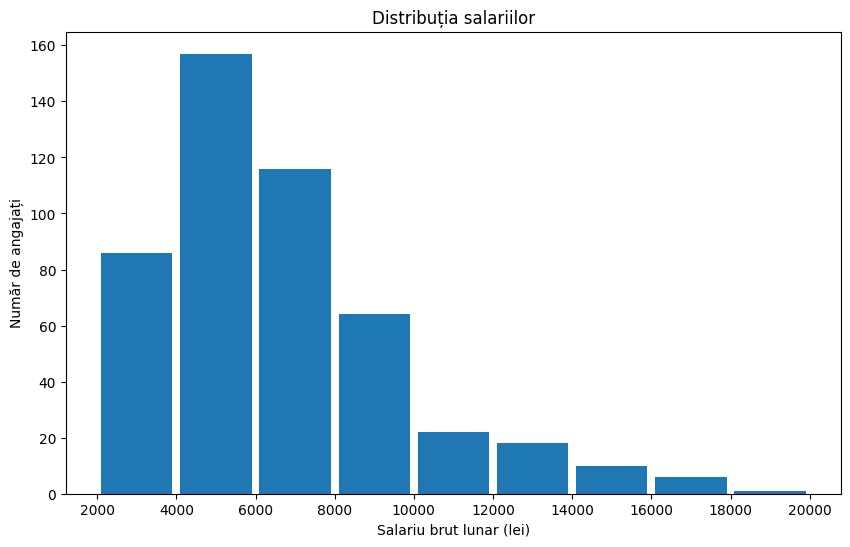

In [43]:
bins = range(2000, 20001, 2000)
plt.figure(figsize=(10, 6))
plt.hist(angajati_analiza["salariu_brut_lunar"],
            bins = bins, 
            rwidth=0.9)

plt.title("Distribuția salariilor")
plt.xlabel("Salariu brut lunar (lei)")
plt.xticks(bins)
plt.ylabel("Număr de angajați")

Observație: Distribuția salariilor este concentrată în principal în intervalele 4.000–8.000 lei, iar numărul angajaților scade pe măsură ce salariile cresc. Salariile de peste 12.000 lei sunt întâlnite mult mai rar, ceea ce determină o distribuție asimetrică spre dreapta.

## 2. Salariul mediu pe nivel

In [44]:
salariu_mediu_nivel = angajati_analiza.groupby("nivel")["salariu_brut_lunar"].mean().round(2)

salariu_mediu_nivel = salariu_mediu_nivel.sort_values(ascending=True)

salariu_mediu_nivel

nivel
Junior      4451.91
Mid         5953.02
Senior      8846.27
Manager    11974.29
Name: salariu_brut_lunar, dtype: float64

Text(0, 0.5, 'Salariu mediu brut lunar (lei)')

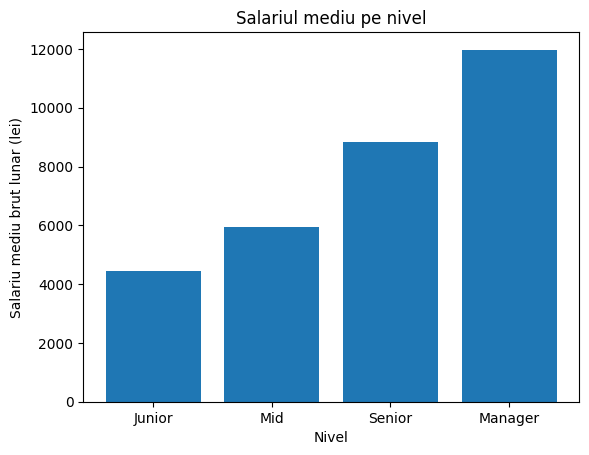

In [45]:
plt.bar(salariu_mediu_nivel.index, salariu_mediu_nivel.values)

plt.title("Salariul mediu pe nivel")
plt.xlabel("Nivel")
plt.ylabel("Salariu mediu brut lunar (lei)")

Observație: Salariul mediu crește odată cu nivelul profesional. Juniorii au un salariu mediu de aproximativ 4.452 lei, în timp ce Managerii ajung la aproximativ 11.974 lei. Cea mai mare creștere se observă între nivelurile Mid și Senior, de la aproximativ 5.953 lei la 8.846 lei.

## 3. Rata de plecare pe departament

In [46]:
rata_plecare_departament = round(angajati_analiza.groupby("nume_departament")["plecat"].mean() * 100, 2)
rata_plecare_departament = rata_plecare_departament.sort_values(ascending = False)

rata_plecare_departament

nume_departament
Vânzări           39.29
Suport Clienți    31.76
Juridic           25.00
Marketing         23.26
Financiar         19.44
Operațiuni        16.46
IT                16.07
Resurse Umane     12.00
Name: plecat, dtype: float64

Text(0, 0.5, 'Rata de plecare (%)')

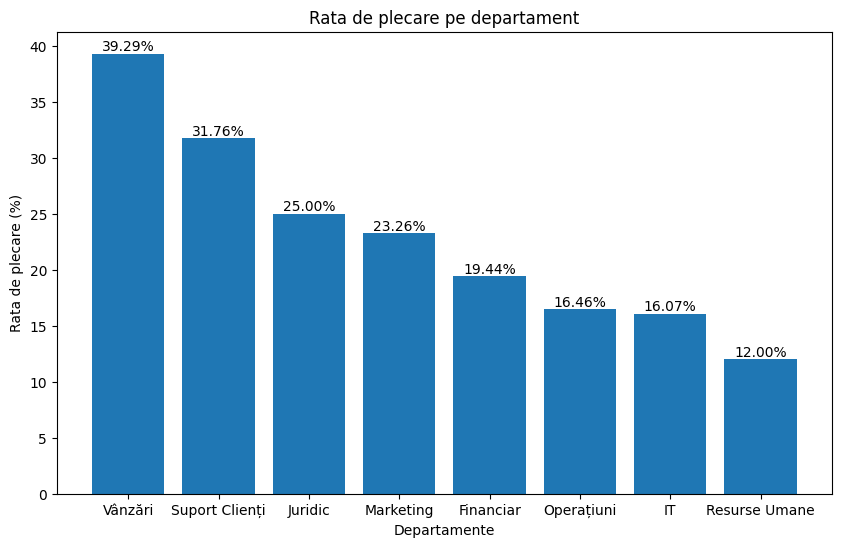

In [47]:
plt.figure(figsize=(10,6))
bare = plt.bar(rata_plecare_departament.index, rata_plecare_departament.values)

plt.bar_label(bare, fmt="%.2f%%")

plt.title("Rata de plecare pe departament")
plt.xlabel("Departamente")
plt.ylabel("Rata de plecare (%)")


Observație: Cea mai mare rată de plecare se înregistrează în departamentul Vânzări (39,29%), urmat de Suport Clienți (31,76%). La polul opus, Resurse Umane are cea mai mică rată de plecare (12%). Diferențele dintre departamente sugerează că fluctuația de personal este mai accentuată în anumite zone ale companiei.

## 4. Distribuția angajaților după status

In [48]:
status_angajati = angajati_analiza["status"].value_counts()

Text(0.5, 1.0, 'Distribuția angajaților după status')

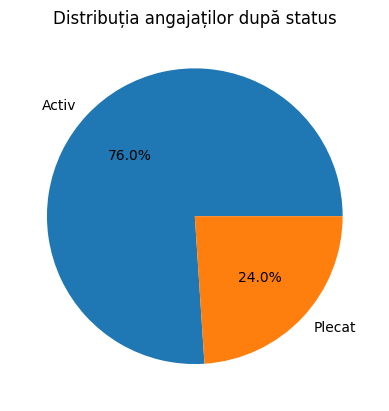

In [49]:
plt.pie(
    status_angajati.values,
    labels=status_angajati.index,
    autopct="%1.1f%%"
)

plt.title("Distribuția angajaților după status")

Observație: Majoritatea angajaților sunt activi (76%), în timp ce 24% au părăsit compania. Astfel, aproximativ un sfert dintre angajații din setul de date au statusul „Plecat”.

## 5. Evoluția angajărilor și plecărilor

([<matplotlib.axis.XTick at 0x126906350>,
 [Text(2016, 0, '2016'),
  Text(2017, 0, '2017'),
  Text(2018, 0, '2018'),
  Text(2019, 0, '2019'),
  Text(2020, 0, '2020'),
  Text(2021, 0, '2021'),
  Text(2022, 0, '2022'),
  Text(2023, 0, '2023'),
  Text(2024, 0, '2024'),
  Text(2025, 0, '2025')])

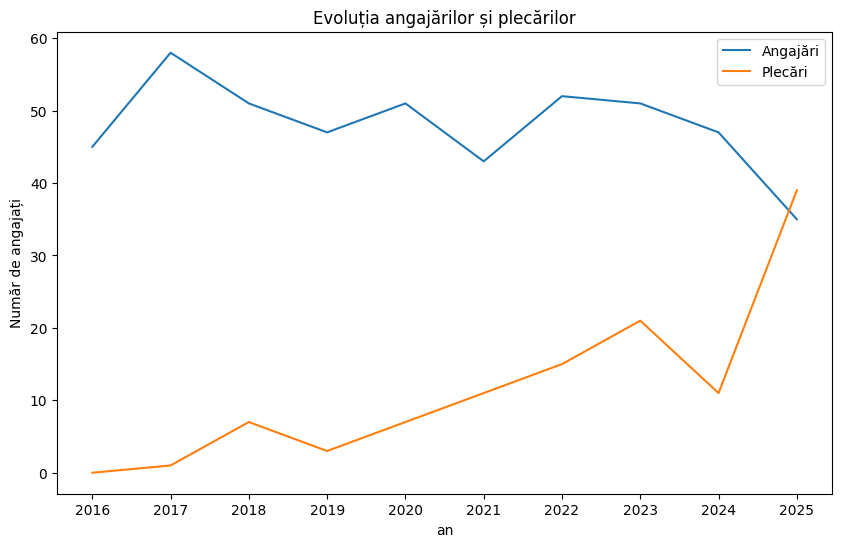

In [50]:
plt.figure(figsize=(10,6))

plt.plot(tabel_ani["an"], tabel_ani["angajari"], label="Angajări")
plt.plot(tabel_ani["an"], tabel_ani["plecari"], label="Plecări")

plt.title("Evoluția angajărilor și plecărilor")
plt.xlabel("an")
plt.ylabel("Număr de angajați")
plt.legend()
plt.xticks(tabel_ani["an"])


Observație: Numărul angajărilor a fost relativ stabil până în 2024, în timp ce plecările au avut, în general, o tendință de creștere. În 2025 situația se inversează: plecările (39) depășesc angajările (35), ceea ce poate indica o problemă de retenție a personalului.